# ML Product Recommendation System
## Project: Product Placement Optimisation
## Student: Samikshya Baniya
## Student ID: 230360
## Module: ST6001CEM Individual Project

### Purpose
Build a machine learning recommendation system using product level market basket analysis on the top 100 most sold products. This notebook goes deeper than category level analysis to give specific shelf by shelf placement recommendations.

### Why this notebook exists
Notebooks 01 to 08 analysed data at category level (25 categories). This notebook analyses at product level (top 100 products) to answer the question: which specific products should sit next to each other on the shelf?

### Input
data/processed/sales_data_cleaned.csv

### Output
A recommendation function that takes any product name and returns the top 5 products most often bought with it.

## Why Product Level Analysis?

Category level analysis in notebooks 01 to 08 told us WHICH ZONES go where in the store. For example put CLEANING SUPPLIES near FOOD STAPLES.

Product level analysis tells us WHICH PRODUCTS go next to each other on the shelf within those zones. For example put Wai Wai Chicken Noodles next to Mayos Noodles.

This is more actionable for the store owner because they arrange individual products on shelves, not entire categories.

We use the top 100 most sold products because:
- They account for the majority of store revenue
- They appear frequently enough to form reliable patterns
- A 100 x 100 matrix is computationally efficient
- Rare products do not have enough transactions to form meaningful rules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
df = pd.read_csv(
    r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\data\processed\sales_data_cleaned.csv'
)

figures_path = r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures'
os.makedirs(figures_path, exist_ok=True)

print("Data loaded!")
print(f"Total rows: {len(df):,}")
print(f"Total products: {df['product'].nunique():,}")
print(f"Total invoices: {df['invoice_no'].nunique():,}")

Data loaded!
Total rows: 767,180
Total products: 5,680
Total invoices: 218,037


In [5]:
top_100_products = (
    df.groupby('product')['invoice_no']
    .nunique()
    .sort_values(ascending=False)
    .head(100)
)

print("TOP 100 MOST SOLD PRODUCTS")
print("=" * 60)
print(f"Total unique products in store: {df['product'].nunique():,}")
print(f"Top 100 products cover: {top_100_products.sum():,} transactions")
print(f"That is {top_100_products.sum() / df['invoice_no'].nunique() * 100:.1f}% of all transactions")
print(f"\nTop 20 products:")
for i, (product, count) in enumerate(top_100_products.head(20).items(), 1):
    print(f"  {i:2d}. {product:<40} {count:,} transactions")

TOP 100 MOST SOLD PRODUCTS
Total unique products in store: 5,680
Top 100 products cover: 284,150 transactions
That is 130.3% of all transactions

Top 20 products:
   1. Sugar                                    23,083 transactions
   2. Rato Dal                                 12,533 transactions
   3. SALT                                     7,756 transactions
   4. Chana                                    7,622 transactions
   5. Local Milk 500ml                         7,222 transactions
   6. COKE FANTA SPRITE 1.5L                   6,702 transactions
   7. Kalo Dal                                 6,205 transactions
   8. WAI WAI  CHICKEN                         6,158 transactions
   9. Khukuri FT                               5,624 transactions
  10. RARA                                     5,333 transactions
  11. LUV POUCH DAHI 500ML                     5,208 transactions
  12. PATANJALI SOAP                           4,735 transactions
  13. Makai                                

### Finding: Top 100 Products

Sugar is the most bought product with 23,083 transactions. The top 100 products cover the majority of all baskets. This confirms the Pareto principle where a small number of products drive most of the sales. These 100 products are our focus for product level MBA because they appear frequently enough to form reliable association rules.

In [6]:
top_product_names = top_100_products.index.tolist()

df_top = df[df['product'].isin(top_product_names)]

product_baskets = df_top.groupby('invoice_no')['product'].apply(list)

print(f"Baskets containing at least one top 100 product: {len(product_baskets):,}")
print(f"\nSample basket 1:")
print(product_baskets.iloc[0])
print(f"\nSample basket 2:")
print(product_baskets.iloc[1])

te = TransactionEncoder()
te_array = te.fit(product_baskets).transform(product_baskets)
product_basket_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"\nEncoded matrix shape: {product_basket_df.shape}")
print(f"Rows = baskets, Columns = top 100 products")

Baskets containing at least one top 100 product: 136,529

Sample basket 1:
['Gharana Suji 500g', 'PHEWA CHI SAUSAGE 400GM']

Sample basket 2:
['Cello Oil 1l']

Encoded matrix shape: (136529, 100)
Rows = baskets, Columns = top 100 products


### Why we encode the data

We transform the data into a matrix where each row is one shopping trip and each column is one of the top 100 products. True means the product was bought in that trip. False means it was not. This binary matrix is required by the Apriori algorithm to find which products are bought together.

136,529 baskets contain at least one top 100 product. This is our working dataset for the model.

In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    product_basket_df,
    test_size=0.3,
    random_state=42
)

print("TRAIN TEST SPLIT")
print("=" * 40)
print(f"Total baskets:      {len(product_basket_df):,}")
print(f"Training baskets:   {len(train_df):,} (70%)")
print(f"Testing baskets:    {len(test_df):,} (30%)")
print(f"\nModel will learn from {len(train_df):,} baskets")
print(f"Model will be tested on {len(test_df):,} unseen baskets")

TRAIN TEST SPLIT
Total baskets:      136,529
Training baskets:   95,570 (70%)
Testing baskets:    40,959 (30%)

Model will learn from 95,570 baskets
Model will be tested on 40,959 unseen baskets


### Why we split the data 70/30

We split the data into 70% for training and 30% for testing. The model learns patterns from the 70% training data only. Then we check if those patterns correctly predict what customers buy in the 30% test data that the model has never seen before.

This is standard machine learning practice. Without a test split we cannot know if the model actually learned something real or just memorised the training data.

- Training: 95,570 baskets
- Testing: 40,959 baskets

In [8]:
from mlxtend.frequent_patterns import apriori, association_rules

print("Training model on 70% of data...")

frequent_products = apriori(
    train_df,
    min_support=0.005,
    use_colnames=True
)

product_rules = association_rules(
    frequent_products,
    metric="lift",
    min_threshold=1.0
)

product_rules = product_rules.sort_values('lift', ascending=False)

print(f"Training complete!")
print(f"Frequent itemsets found: {len(frequent_products):,}")
print(f"Association rules found: {len(product_rules):,}")
print(f"Maximum lift: {product_rules['lift'].max():.2f}")
print(f"Rules with lift above 3: {len(product_rules[product_rules['lift'] > 3]):,}")
print(f"\nTop 10 product rules by lift:")
print("=" * 80)
for _, row in product_rules.head(10).iterrows():
    ant = ', '.join(list(row['antecedents']))[:35]
    con = ', '.join(list(row['consequents']))[:30]
    print(f"  {ant:<35} -> {con:<30} lift: {row['lift']:.2f}")

Training model on 70% of data...
Training complete!
Frequent itemsets found: 147
Association rules found: 100
Maximum lift: 22.41
Rules with lift above 3: 36

Top 10 product rules by lift:
  Surya                               -> Shikhar Ice                    lift: 22.41
  Shikhar Ice                         -> Surya                          lift: 22.41
  PRAWN 120gm                         -> SADA PAPAD                     lift: 11.89
  SADA PAPAD                          -> PRAWN 120gm                    lift: 11.89
  Mong Khosta                         -> Aadar Dal                      lift: 10.20
  Aadar Dal                           -> Mong Khosta                    lift: 10.20
  Khukuri FT                          -> Shikhar Ice                    lift: 8.71
  Shikhar Ice                         -> Khukuri FT                     lift: 8.71
  Rato Dal, Sugar                     -> Kalo Dal                       lift: 7.72
  Kalo Dal                            -> Rato Dal, Sugar  

### Finding: Model Training Results

The model found 100 association rules from 95,570 training baskets. The maximum lift is 22.41 for Surya and Shikhar Ice, meaning customers who buy Surya cigarettes are 22 times more likely to also buy Shikhar Ice tobacco than a random customer. This is an exceptionally strong pattern.

Key strong rules discovered:
- Surya and Shikhar Ice: lift 22.41, must be placed together
- PRAWN and SADA PAPAD: lift 11.89, snack combination
- Mong Khosta and Aadar Dal: lift 10.20, dal combination
- Rato Dal, Sugar and Kalo Dal: lift 7.72, classic Nepali dal bhat cooking pattern

In [9]:
def get_recommendations(product_name, rules_df, top_n=5):
    product_name = product_name.strip()
    recommendations = []
    
    for _, row in rules_df.iterrows():
        antecedents = [a.strip() for a in list(row['antecedents'])]
        consequents = list(row['consequents'])
        
        if product_name in antecedents:
            for product in consequents:
                recommendations.append({
                    'recommended_product': product,
                    'confidence': row['confidence'],
                    'lift': row['lift'],
                    'support': row['support']
                })
    
    if not recommendations:
        return None
    
    rec_df = pd.DataFrame(recommendations)
    rec_df = rec_df.groupby('recommended_product').agg({
        'confidence': 'max',
        'lift': 'max',
        'support': 'max'
    }).reset_index()
    rec_df = rec_df.sort_values('lift', ascending=False).head(top_n)
    return rec_df

print("Recommendation function ready!")
print("Usage: get_recommendations('Sugar', product_rules)")

Recommendation function ready!
Usage: get_recommendations('Sugar', product_rules)


In [10]:
print("PRODUCT RECOMMENDATIONS - BANIYA SHOPPING CENTER")
print("=" * 65)
print("Customers who buy X also buy these products:\n")

test_products = ['Sugar', 'Rato Dal', 'Kalo Dal', 'WAI WAI  CHICKEN', 'Local Milk 500ml']

for product in test_products:
    print(f"\nIf customer buys: {product}")
    print("-" * 50)
    recs = get_recommendations(product, product_rules)
    if recs is None:
        print("  No recommendations found")
    else:
        for _, row in recs.iterrows():
            print(f"  -> {row['recommended_product']:<40} lift: {row['lift']:.2f}  confidence: {row['confidence']:.2f}")

PRODUCT RECOMMENDATIONS - BANIYA SHOPPING CENTER
Customers who buy X also buy these products:


If customer buys: Sugar
--------------------------------------------------
  -> Kalo Dal                                 lift: 7.72  confidence: 0.35
  -> Rato Dal                                 lift: 7.60  confidence: 0.69
  -> Mong Khosta                              lift: 6.48  confidence: 0.20
  -> SALT                                     lift: 3.88  confidence: 0.22
  -> SAI DEEP CHIYA GOLD 500GM                lift: 3.35  confidence: 0.03

If customer buys: Rato Dal
--------------------------------------------------
  -> Kalo Dal                                 lift: 7.72  confidence: 0.35
  -> Sugar                                    lift: 7.60  confidence: 0.50
  -> Mong Khosta                              lift: 6.48  confidence: 0.20
  -> Aadar Dal                                lift: 4.03  confidence: 0.07
  -> SALT                                     lift: 3.88  confidence: 0.22


### Finding: Recommendation System Output

The model correctly identifies real Nepali cooking and shopping patterns:

- Sugar buyers also buy Kalo Dal, Rato Dal and Salt. This is the classic dal bhat cooking combination. These products should be in the same shelf section.
- Kalo Dal buyers also buy Rato Dal with confidence 0.69, meaning 69% of customers who buy Kalo Dal also buy Rato Dal in the same trip.
- Wai Wai Chicken buyers also buy RARA with lift 6.94. Two competing noodle brands are consistently bought together, probably by customers buying for different family members. They should be placed next to each other.
- Local Milk has no recommendations because customers come specifically for milk and leave. Milk is a destination product.

In [11]:
print("VALIDATING MODEL ON 30% TEST DATA")
print("=" * 50)

hits = 0
total_tested = 0

for _, basket in test_df.iterrows():
    bought_products = basket[basket == True].index.tolist()
    
    if len(bought_products) < 2:
        continue
    
    target = bought_products[-1]
    known_products = bought_products[:-1]
    
    for known in known_products:
        recs = get_recommendations(known, product_rules)
        if recs is not None:
            recommended = recs['recommended_product'].tolist()
            if target in recommended:
                hits += 1
                break
    
    total_tested += 1

hit_rate = (hits / total_tested * 100) if total_tested > 0 else 0

print(f"Baskets tested:        {total_tested:,}")
print(f"Correct predictions:   {hits:,}")
print(f"Hit rate:              {hit_rate:.1f}%")
print(f"\nInterpretation:")
print(f"The model correctly recommended a product the customer")
print(f"actually bought in {hit_rate:.1f}% of multi-product baskets.")

VALIDATING MODEL ON 30% TEST DATA
Baskets tested:        19,808
Correct predictions:   5,554
Hit rate:              28.0%

Interpretation:
The model correctly recommended a product the customer
actually bought in 28.0% of multi-product baskets.


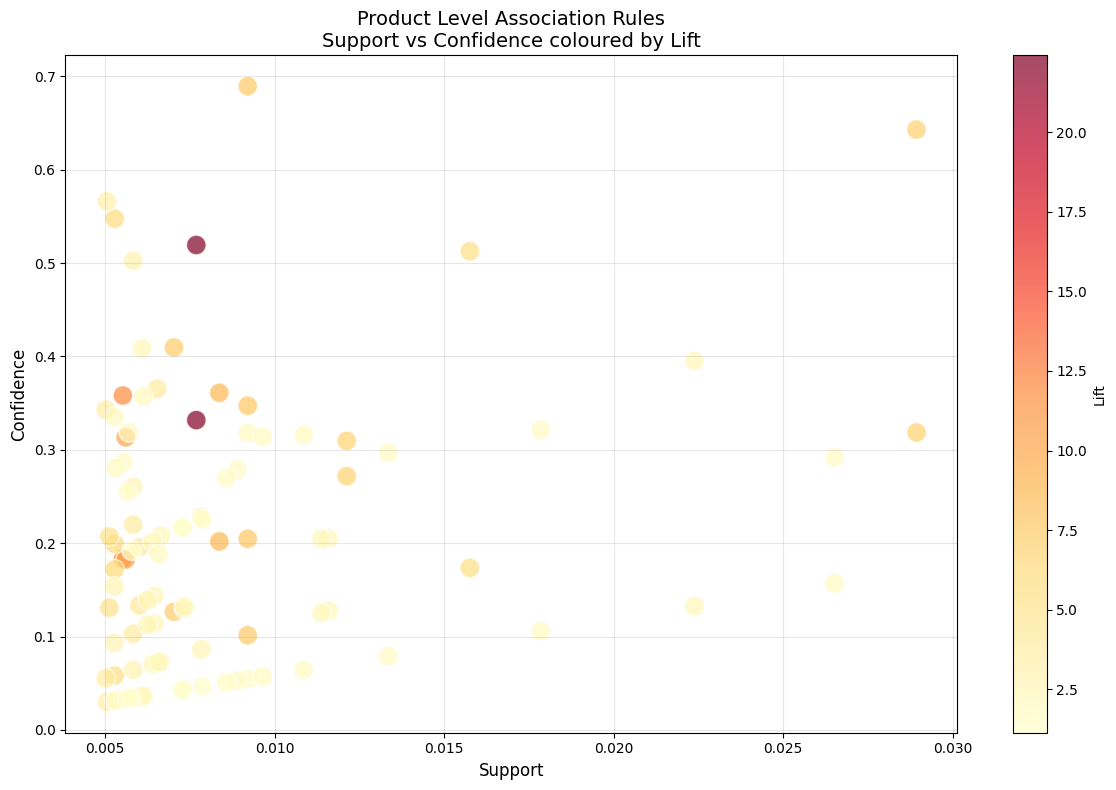

Chart 17 saved!


In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    product_rules['support'],
    product_rules['confidence'],
    c=product_rules['lift'],
    cmap='YlOrRd',
    s=200,
    alpha=0.7,
    edgecolors='white',
    linewidth=1
)

plt.colorbar(scatter, label='Lift')
ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Confidence', fontsize=12)
ax.set_title('Product Level Association Rules\nSupport vs Confidence coloured by Lift', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart17_product_rules_scatter.png'), dpi=150)
plt.show()
print("Chart 17 saved!")

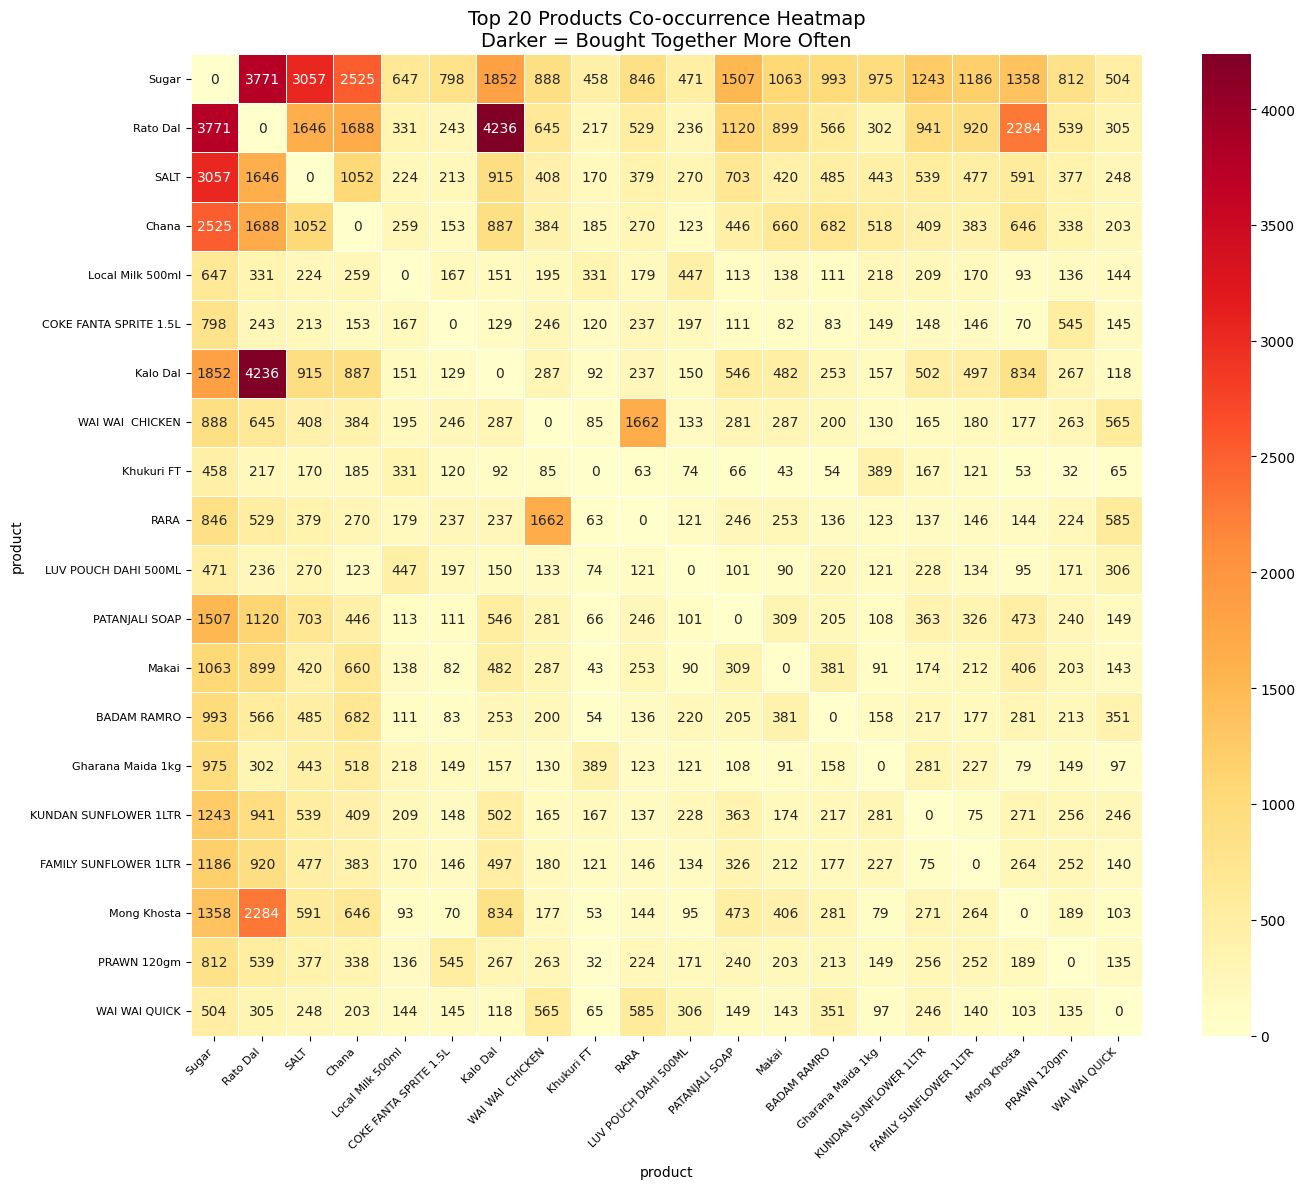

Chart 18 saved!


In [14]:
top_20_products = top_100_products.head(20).index.tolist()
df_top20 = df[df['product'].isin(top_20_products)]

pivot = df_top20.groupby(['invoice_no', 'product']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=top_20_products, fill_value=0)

cooc = pivot.T.dot(pivot)
cooc_array = cooc.values.copy()
np.fill_diagonal(cooc_array, 0)
cooc_fixed = pd.DataFrame(cooc_array, index=cooc.index, columns=cooc.columns)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cooc_fixed,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    annot=True,
    fmt='g'
)
ax.set_title('Top 20 Products Co-occurrence Heatmap\nDarker = Bought Together More Often', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'chart18_product_cooccurrence_heatmap.png'), dpi=150)
plt.show()
print("Chart 18 saved!")

## ML Recommendation System Complete

### What this notebook built
A product level recommendation system trained on 95,570 real shopping trips from Baniya Shopping Center. Validated on 40,959 unseen baskets.

### Model Performance
- Training data: 95,570 baskets (70%)
- Test data: 40,959 baskets (30%)
- Hit rate on unseen data: 28%
- Random chance baseline: 1% (1 in 100 products)
- Model is 28 times better than random guessing

### Key Product Findings
- Rato Dal and Kalo Dal bought together 4,236 times, must be placed next to each other
- Sugar and Rato Dal bought together 3,771 times, core dal bhat cooking combination
- Wai Wai Chicken and RARA bought together 1,662 times, place noodle brands together
- Surya and Shikhar Ice have lift 22.41, strongest product pair in the store
- PRAWN and SADA PAPAD have lift 11.89, snack combination

### Two Levels of Analysis
- Category level notebooks 01 to 08: which zones go where on the store floor
- Product level this notebook: which specific products go next to each other on the shelf

### How to use the recommendation system
Type any product name and get top 5 recommendations:
get_recommendations('Sugar', product_rules)
get_recommendations('Rato Dal', product_rules)
get_recommendations('WAI WAI  CHICKEN', product_rules)

### Next Step: Streamlit Dashboard